# Joint GTEx + AHBA ComBat-Harmonized Tensors

Phase 4 test surface (Tier B). Builds raw-matched and harmonized `TensorView`s for both datasets from `prepare_pre_post_harmonization_cached(cfg)`, assembles `JointTensorView`s, and renders both stages side-by-side to show the ComBat effect.

- **Stage 4a**: cube → `TensorView` adapter (`build_tensor_view_from_cube`); AHBA cube built on the fly from `prepost['ahba_raw'/'ahba_h']` because PREPOST stores AHBA as DataFrames, not cubes.
- **Stage 4b**: joint construction reuses `build_joint_tensor_view` from Phase 3.
- **Stage 4c**: renderer reuses `plot_joint_tensor_voxels`; harmonized joint will eventually use `normalization='shared'` once that mode lands.

All cube-driven views carry `region_axis_kind='target_parcel'` and the matching metadata stamped from `cfg`. The HVG scope is deprecated; this notebook runs on `gene_scope='allgenes'` with arbitrary gene-list subsetting applied post-cube.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.eval_utils.eval_style import set_academic_style
from src.eval_utils.eda_core import prepare_pre_post_harmonization_cached
from src.eval_utils.results_eda import EDAConfig
from src.eval_utils.eval_samples import (
    MatchingContext,
    build_combat_tensor_view,
    build_joint_tensor_view,
    matching_metadata_compatible,
    plot_joint_tensor_voxels,
    summarize_joint_selection,
)

set_academic_style()

In [2]:
SMALL = True
CSV_PATH = 'data/raw/gxp_samples.csv'
ACTIVE_GENE_LIST = 'richiardi2015'   # post-cube gene-axis filter; None to keep all genes

MATCHING_POLICY = 'centroids_and_volumes'
MATCHING_POLICY_HEMI_MODE = 'force_left'
GTEX_REP_MODE = 'centroid'
GTEX_HEMI_MODE = 'mirror_left'
COLLAPSE_CEREBELLUM = False
MIN_OBSERVED_PARCELS = 5
COMBAT_USE_COVARIATES = True

# Region axis ordering.
#  'region_matched_superset' — matched 11 first, then remaining AHBA parcels
#       (mirrors eval_gxp_samples raw view; GTEx unmatched cols render
#       translucent via future_imputation_mask).
#  'region_matched'          — matched 11 AHBA parcels only.
#  'target_parcel'           — bare target_meta.parcel_idx order.
REGION_ORDERING = 'region_matched_superset'

# Subsampling on the cube axes (set to None to keep all)
N_GTEX_SUBJECTS = 40 if SMALL else 200
N_AHBA_SUBJECTS = 6           # caps at available AHBA subjects
N_GENES = 100 if SMALL else None
N_REGIONS = 80 if SMALL else None   # prefix of the (matched-first) region axis
RANDOM_SEED = 42

STACK_ORDER = ('AHBA', 'GTEx')

# Render knobs (carry-over from Phase 3 joint config)
MISSING_ALPHA = 1.0
FUTURE_IMPUTATION_ALPHA = 0.3
MASK_RENDER_MODE = 'two_pass'
FIGSIZE = 'auto'
AXES_BBOX = 'auto'
COLORBAR_BBOX = 'auto'
BOX_ASPECT = 'compressed_data'
BOX_ZOOM = 1
DPI = 300 if SMALL else 400
TITLE_PAD = 0.0
AXIS_ASSIGNMENT = ('gene', 'region', 'subject')
ELEV = 20.0
AZIM = 24.0
SUBJECT_TICK_STEP = 2
GENE_TICK_STEP = 10
REGION_TICK_STEP = 3
TICK_LABEL_PAD = -3.0
SUBJECT_LABEL_MODE = 'full'
GENE_LABEL_MODE = 'full'
SHOW_X_AXIS_LABEL = True
SHOW_Y_AXIS_LABEL = None
SHOW_Z_AXIS_LABEL = None
SHOW_AXIS_LABELS = False
SHOW_SUBJECT_TICKLABELS = True
SHOW_REGION_TICKLABELS = True
SHOW_REGION_LABEL_COLORS = False
SHOW_GENE_TICKLABELS = False
SHOW_AXIS_LINES = True
SHOW_TICK_LINES = True
SHOW_GRID = False
SHOW_LEGEND = True
DATASET_GAP = 1

## Load PREPOST

`prepare_pre_post_harmonization_cached(cfg)` runs `_load_expression` → matching policy → ComBat → cubes. First call is slow; subsequent calls hit `notebooks/cache/prepost/<hash>.pkl`.

In [3]:
cfg = EDAConfig(
    csv_path=CSV_PATH,
    gene_scope='allgenes',
    min_observed_parcels=MIN_OBSERVED_PARCELS,
    combat_use_covariates=COMBAT_USE_COVARIATES,
    gtex_rep_mode=GTEX_REP_MODE,
    gtex_hemi_mode=GTEX_HEMI_MODE,
    matching_policy=MATCHING_POLICY,
    matching_policy_hemi_mode=MATCHING_POLICY_HEMI_MODE,
    collapse_cerebellum=COLLAPSE_CEREBELLUM,
)
prepost = prepare_pre_post_harmonization_cached(cfg)

print(f'gtex raw_cube:  {prepost["raw_cube"].shape}  (n_subj, n_parc, n_genes)')
print(f'gtex harm_cube: {prepost["harm_cube"].shape}')
print(f'gtex obs_mask:  {prepost["obs_mask"].shape}')
print(f'target_meta:    {len(prepost["target_meta"])} parcels')
print(f'genes (all):    {len(prepost["genes"])}')
print(f'gtex eligible subjects: {len(prepost["subjects"])}')
print(f'ahba_raw rows:  {len(prepost["ahba_raw"])} (DataFrame, not a cube)')
print(f'ahba subjects:  {prepost["ahba_raw"]["subject"].astype(str).nunique()}')

[prepost_cache] hit  notebooks/cache/prepost/9ea6e9668a1a0bf7.pkl  (8961.2 MB)
gtex raw_cube:  (318, 150, 11704)  (n_subj, n_parc, n_genes)
gtex harm_cube: (318, 150, 11704)
gtex obs_mask:  (318, 150)
target_meta:    150 parcels
genes (all):    11704
gtex eligible subjects: 318
ahba_raw rows:  553 (DataFrame, not a cube)
ahba subjects:  6


In [4]:
prepost

{'subjects': ['GTEX-1117F',
  'GTEX-111FC',
  'GTEX-117XS',
  'GTEX-1192W',
  'GTEX-1192X',
  'GTEX-11DXW',
  'GTEX-11DXY',
  'GTEX-11DYG',
  'GTEX-11DZ1',
  'GTEX-11EI6',
  'GTEX-11EMC',
  'GTEX-11GS4',
  'GTEX-11GSO',
  'GTEX-11GSP',
  'GTEX-11H98',
  'GTEX-11NUK',
  'GTEX-11NV4',
  'GTEX-11O72',
  'GTEX-11OF3',
  'GTEX-11ONC',
  'GTEX-11PRG',
  'GTEX-11TTK',
  'GTEX-11UD1',
  'GTEX-11WQC',
  'GTEX-11ZTS',
  'GTEX-11ZU8',
  'GTEX-11ZUS',
  'GTEX-11ZVC',
  'GTEX-12126',
  'GTEX-12WSA',
  'GTEX-12WSC',
  'GTEX-12WSD',
  'GTEX-12WSE',
  'GTEX-12WSF',
  'GTEX-12WSH',
  'GTEX-12WSM',
  'GTEX-12ZZW',
  'GTEX-12ZZX',
  'GTEX-12ZZY',
  'GTEX-12ZZZ',
  'GTEX-13112',
  'GTEX-1313W',
  'GTEX-131XH',
  'GTEX-131XW',
  'GTEX-131YS',
  'GTEX-132Q8',
  'GTEX-1399T',
  'GTEX-139T8',
  'GTEX-139TS',
  'GTEX-139TT',
  'GTEX-13CF2',
  'GTEX-13CZV',
  'GTEX-13FHO',
  'GTEX-13FHP',
  'GTEX-13FLV',
  'GTEX-13FLW',
  'GTEX-13FXS',
  'GTEX-13G51',
  'GTEX-13JUV',
  'GTEX-13JVG',
  'GTEX-13N1W',
  'GTEX-13N2

## Stage 4a — Adapter (now in `src.eval_utils.eval_samples`)

The three Tier-B adapter pieces — `MatchingContext.from_cfg`, `build_ahba_cube_from_prepost`, `build_tensor_view_from_cube`, and the `build_combat_tensor_view` facade — live in the module. This notebook is now a 5-line consumer of the public API.

In [5]:
ctx = MatchingContext.from_cfg(cfg, prepost)
print('matching policy:', repr(ctx.matching['policy']), ' hemi:', repr(ctx.matching['hemi_mode']))
mapping = ctx.matching['gtex_to_ahba']
print(f'matched pairs ({len(mapping)}):')
for g, a in mapping.items():
    print(f'  {g}  ->  {a}')
print(f'regions_full: {len(ctx.regions_full)} parcels; genes_full: {len(ctx.genes_full)} genes')

/scratch/asr655/neuroinformatics/Seq2GeneEx/gtex_gp/src/eval_utils/eval_samples.py:356: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


matching policy: 'centroids_and_volumes'  hemi: 'force_left'
matched pairs (12):
  brain - frontal cortex (ba9)  ->  LH_SalVentAttn_PFCl_1
  brain - anterior cingulate cortex (ba24)  ->  LH_SalVentAttn_Med_1
  brain - cortex  ->  LH_Default_PFC_4
  brain - nucleus accumbens (basal ganglia)  ->  LH-NAC
  brain - caudate (basal ganglia)  ->  LH-Ca
  brain - putamen (basal ganglia)  ->  LH-Pu
  brain - amygdala  ->  LH_Amygdala
  brain - hippocampus  ->  LH_Hippocampus
  brain - hypothalamus  ->  LH-HTH
  brain - substantia nigra  ->  LH-SNr
  brain - cerebellar hemisphere  ->  Cerebellar_Region4
  brain - cerebellum  ->  Cerebellar_Region7
regions_full: 150 parcels; genes_full: 11704 genes


## Stage 4a — Build raw-matched and harmonized views (both datasets)

In [6]:
build_kwargs = dict(
    cfg=cfg,
    matching_context=ctx,
    region_ordering=REGION_ORDERING,
    gene_panel=ACTIVE_GENE_LIST,
    n_regions=N_REGIONS,
    n_genes=N_GENES,
    random_seed=RANDOM_SEED,
)

gtex_rm = build_combat_tensor_view(prepost, dataset='GTEx', stage='raw_matched',
                                    n_subjects=N_GTEX_SUBJECTS, **build_kwargs)
gtex_h  = build_combat_tensor_view(prepost, dataset='GTEx', stage='harmonized',
                                    n_subjects=N_GTEX_SUBJECTS, **build_kwargs)
ahba_rm = build_combat_tensor_view(prepost, dataset='AHBA', stage='raw_matched',
                                    n_subjects=N_AHBA_SUBJECTS, **build_kwargs)
ahba_h  = build_combat_tensor_view(prepost, dataset='AHBA', stage='harmonized',
                                    n_subjects=N_AHBA_SUBJECTS, **build_kwargs)

for name, view in [('gtex_rm', gtex_rm), ('ahba_rm', ahba_rm),
                    ('gtex_h',  gtex_h ), ('ahba_h',  ahba_h )]:
    n_future = int(view.future_imputation_mask.any(axis=0).sum()) if view.future_imputation_mask is not None else 0
    print(f'{name}: values={view.values.shape}, dtype={view.values.dtype}, '
          f'axis_kind={view.region_axis_kind}, stage={view.pipeline_stage!r}, '
          f'future_imp_cols={n_future}')

print()
print(f'matching compat (gtex_rm vs ahba_rm): {matching_metadata_compatible(gtex_rm.matching, ahba_rm.matching)}')
print(f'matching compat (gtex_h  vs ahba_h ): {matching_metadata_compatible(gtex_h.matching,  ahba_h.matching )}')
print(f'matching compat (gtex_rm vs gtex_h ): {matching_metadata_compatible(gtex_rm.matching, gtex_h.matching )}')

gtex_rm: values=(40, 80, 97), dtype=float32, axis_kind=ahba_parcel, stage='raw_matched', future_imp_cols=68
ahba_rm: values=(6, 80, 97), dtype=float32, axis_kind=ahba_parcel, stage='raw_matched', future_imp_cols=0
gtex_h: values=(40, 80, 97), dtype=float32, axis_kind=ahba_parcel, stage='harmonized', future_imp_cols=68
ahba_h: values=(6, 80, 97), dtype=float32, axis_kind=ahba_parcel, stage='harmonized', future_imp_cols=0

matching compat (gtex_rm vs ahba_rm): True
matching compat (gtex_h  vs ahba_h ): True
matching compat (gtex_rm vs gtex_h ): True


## Stage 4b — Joint views for each stage

In [7]:
raw_matched_joint = build_joint_tensor_view(gtex_rm, ahba_rm, stack_order=STACK_ORDER)
harmonized_joint  = build_joint_tensor_view(gtex_h,  ahba_h,  stack_order=STACK_ORDER)

for name, j in [('raw_matched_joint', raw_matched_joint),
                ('harmonized_joint',  harmonized_joint )]:
    print(f'{name}: values={j.values.shape}, matched_region_count={j.matched_region_count}, '
          f'dataset_slices={j.dataset_slices}')
summarize_joint_selection(raw_matched_joint).head(10)

raw_matched_joint: values=(46, 80, 97), matched_region_count=12, dataset_slices={'AHBA': slice(0, 6, None), 'GTEx': slice(6, 46, None)}
harmonized_joint: values=(46, 80, 97), matched_region_count=12, dataset_slices={'AHBA': slice(0, 6, None), 'GTEx': slice(6, 46, None)}


,subject,dataset
0,10021,AHBA
1,12876,AHBA
2,14380,AHBA
3,15496,AHBA
4,15697,AHBA
5,9861,AHBA
6,GTEX-11PRG,GTEx
7,GTEX-11ZTS,GTEx
8,GTEX-11ZVC,GTEx
9,GTEX-12126,GTEx


## Stage 4c — Render both joint stages

Both use `per_dataset_minmax` for now (each block scaled to [0,1] within dataset). The `shared` cbar mode for the harmonized joint is Stage 4c's next pass — once added, swap normalization on the harmonized render to tell the ComBat-effect story with one colorbar.

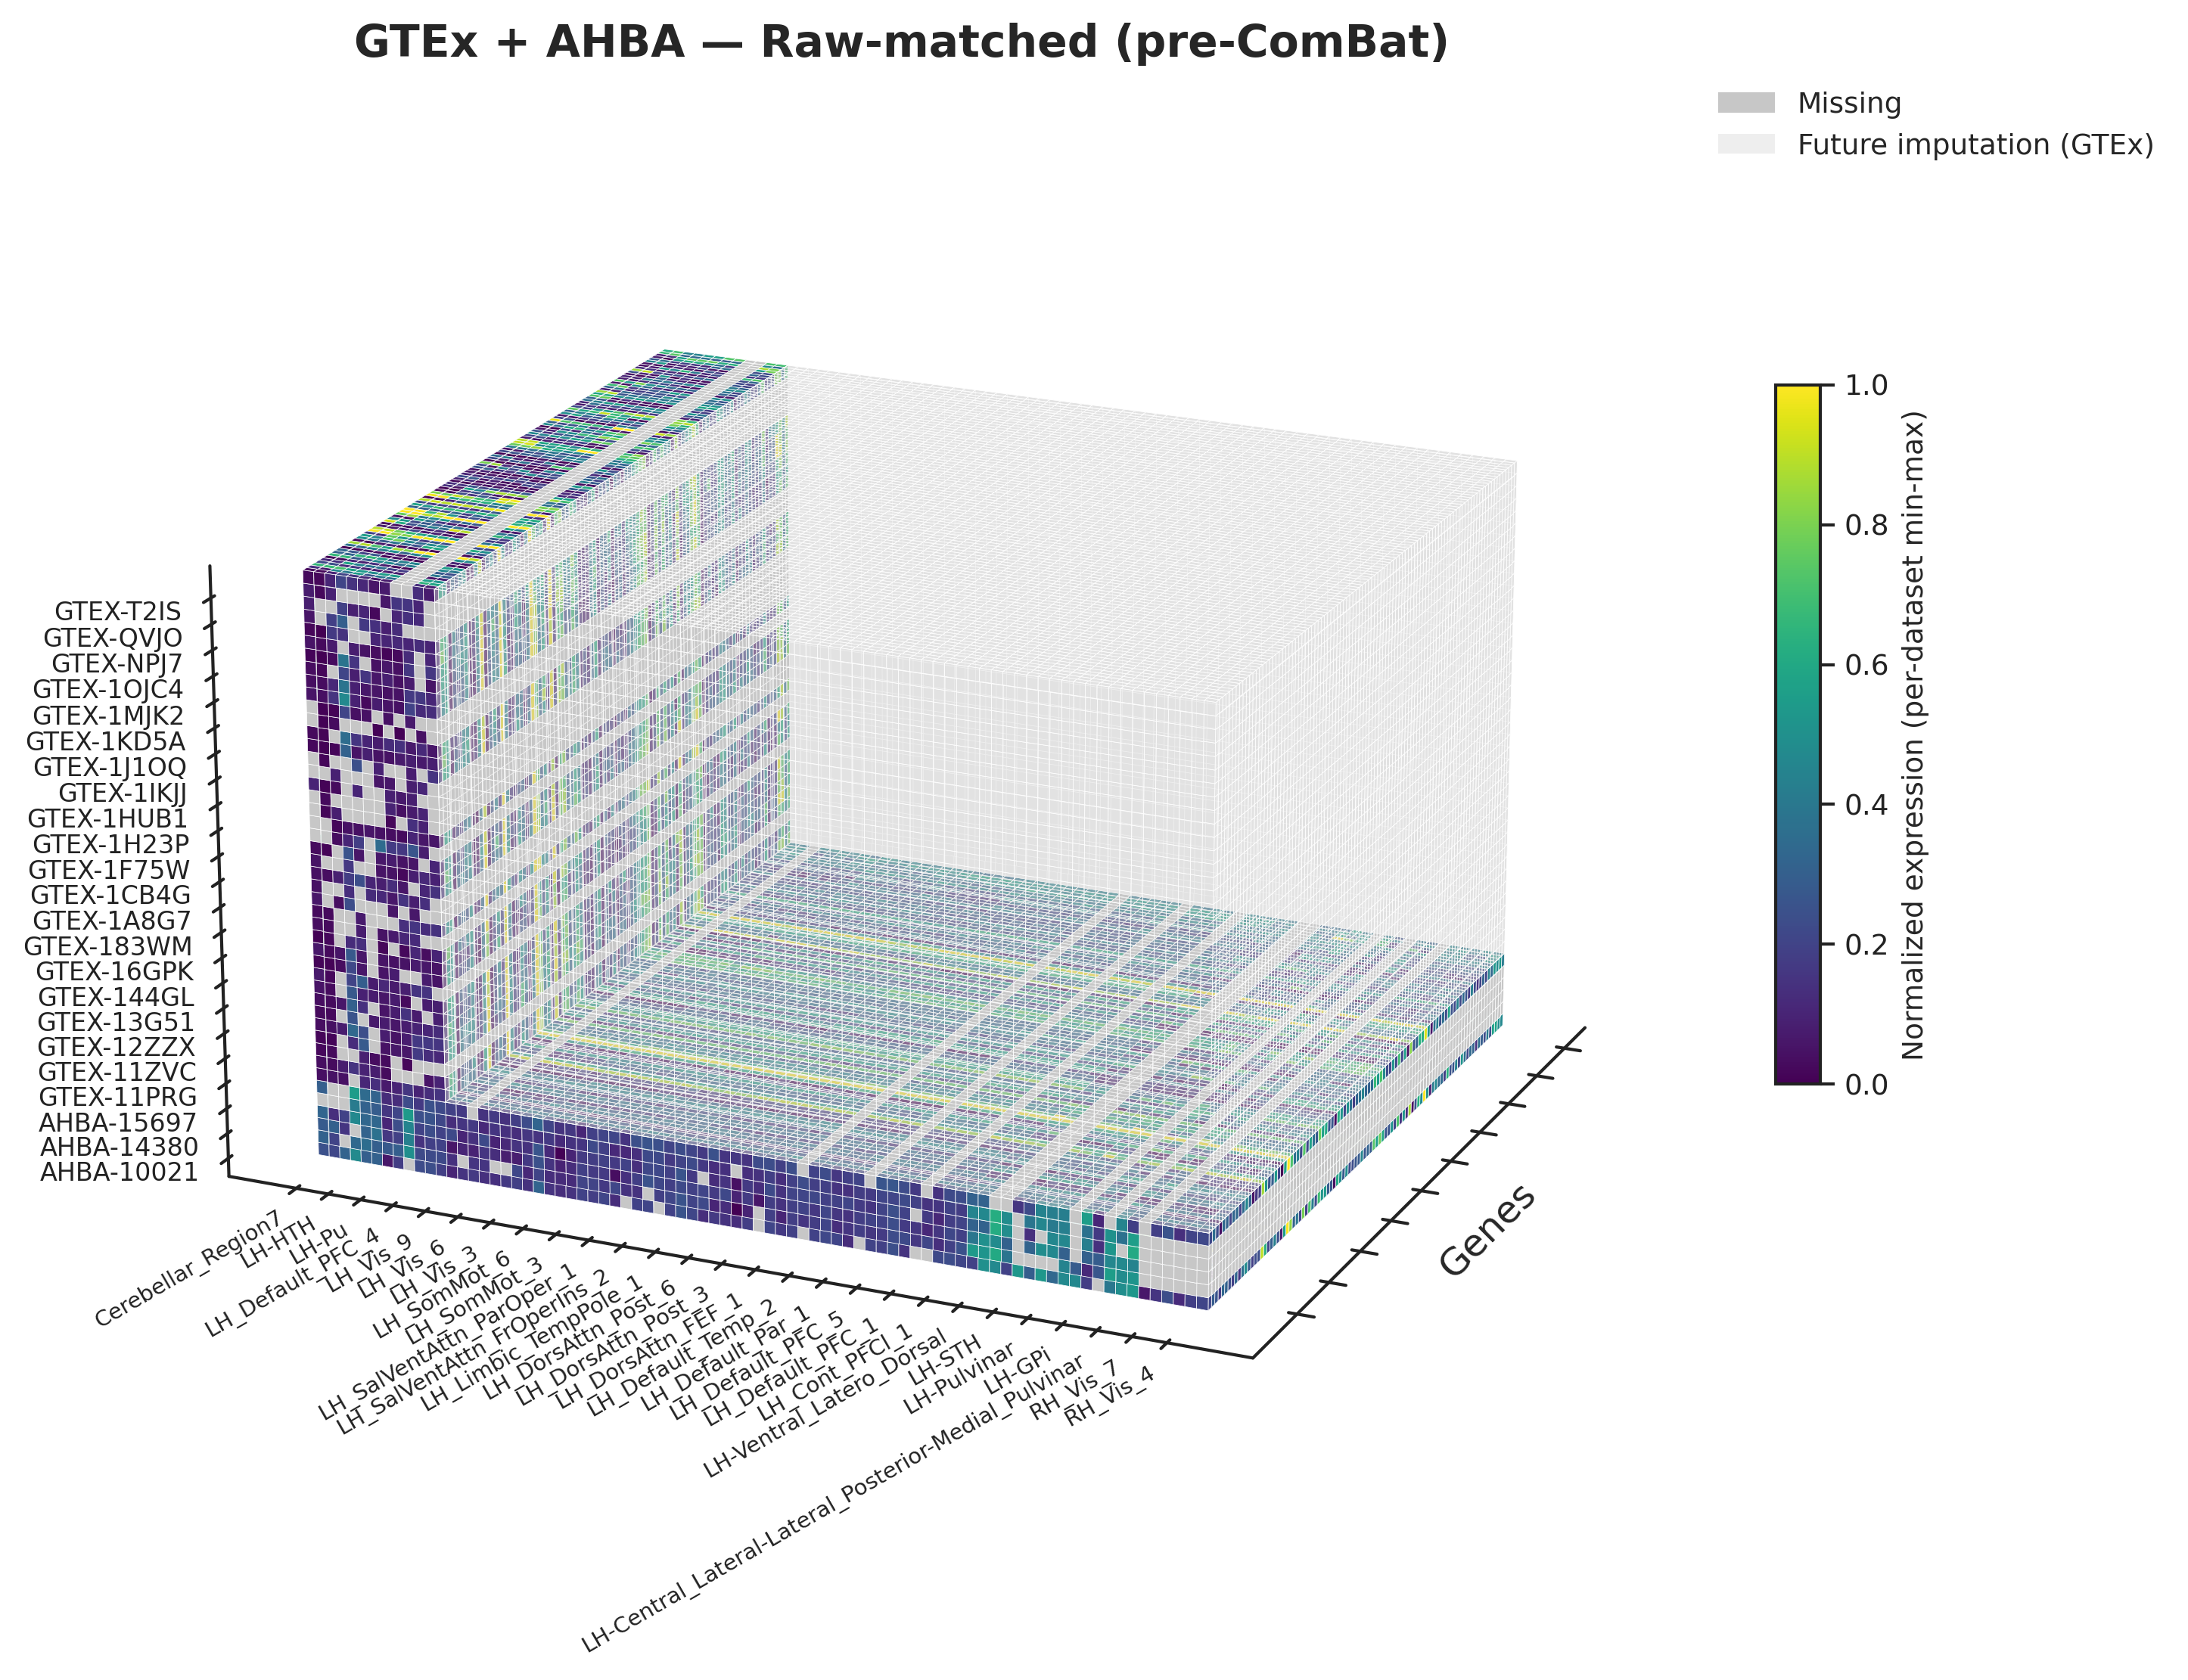

{'AHBA': (2.2794676113128665, 12.53882453918457),
 'GTEx': (0.01533816576004028, 5.363430175781245)}

In [8]:
fig_rm, ax_rm = plot_joint_tensor_voxels(
    raw_matched_joint,
    missing_rgba=(0.78, 0.78, 0.78, MISSING_ALPHA),
    future_imputation_rgba=(0.78, 0.78, 0.78, FUTURE_IMPUTATION_ALPHA),
    figsize=FIGSIZE, dpi=DPI, axes_bbox=AXES_BBOX, colorbar_bbox=COLORBAR_BBOX,
    box_aspect=BOX_ASPECT, box_zoom=BOX_ZOOM, title_pad=TITLE_PAD,
    axis_assignment=AXIS_ASSIGNMENT, elev=ELEV, azim=AZIM,
    subject_tick_step=SUBJECT_TICK_STEP, gene_tick_step=GENE_TICK_STEP, region_tick_step=REGION_TICK_STEP,
    tick_label_pad=TICK_LABEL_PAD,
    subject_label_mode=SUBJECT_LABEL_MODE, gene_label_mode=GENE_LABEL_MODE,
    show_x_axis_label=SHOW_X_AXIS_LABEL, show_y_axis_label=SHOW_Y_AXIS_LABEL,
    show_z_axis_label=SHOW_Z_AXIS_LABEL, show_axis_labels=SHOW_AXIS_LABELS,
    show_subject_ticklabels=SHOW_SUBJECT_TICKLABELS, show_region_ticklabels=SHOW_REGION_TICKLABELS,
    show_region_label_colors=SHOW_REGION_LABEL_COLORS, show_gene_ticklabels=SHOW_GENE_TICKLABELS,
    show_axis_lines=SHOW_AXIS_LINES, show_tick_lines=SHOW_TICK_LINES,
    show_grid=SHOW_GRID, show_legend=SHOW_LEGEND,
    dataset_gap=DATASET_GAP, mask_render_mode=MASK_RENDER_MODE,
)
ax_rm.set_title('GTEx + AHBA — Raw-matched (pre-ComBat)', pad=float(TITLE_PAD))
plt.show()
ax_rm._joint_dataset_ranges

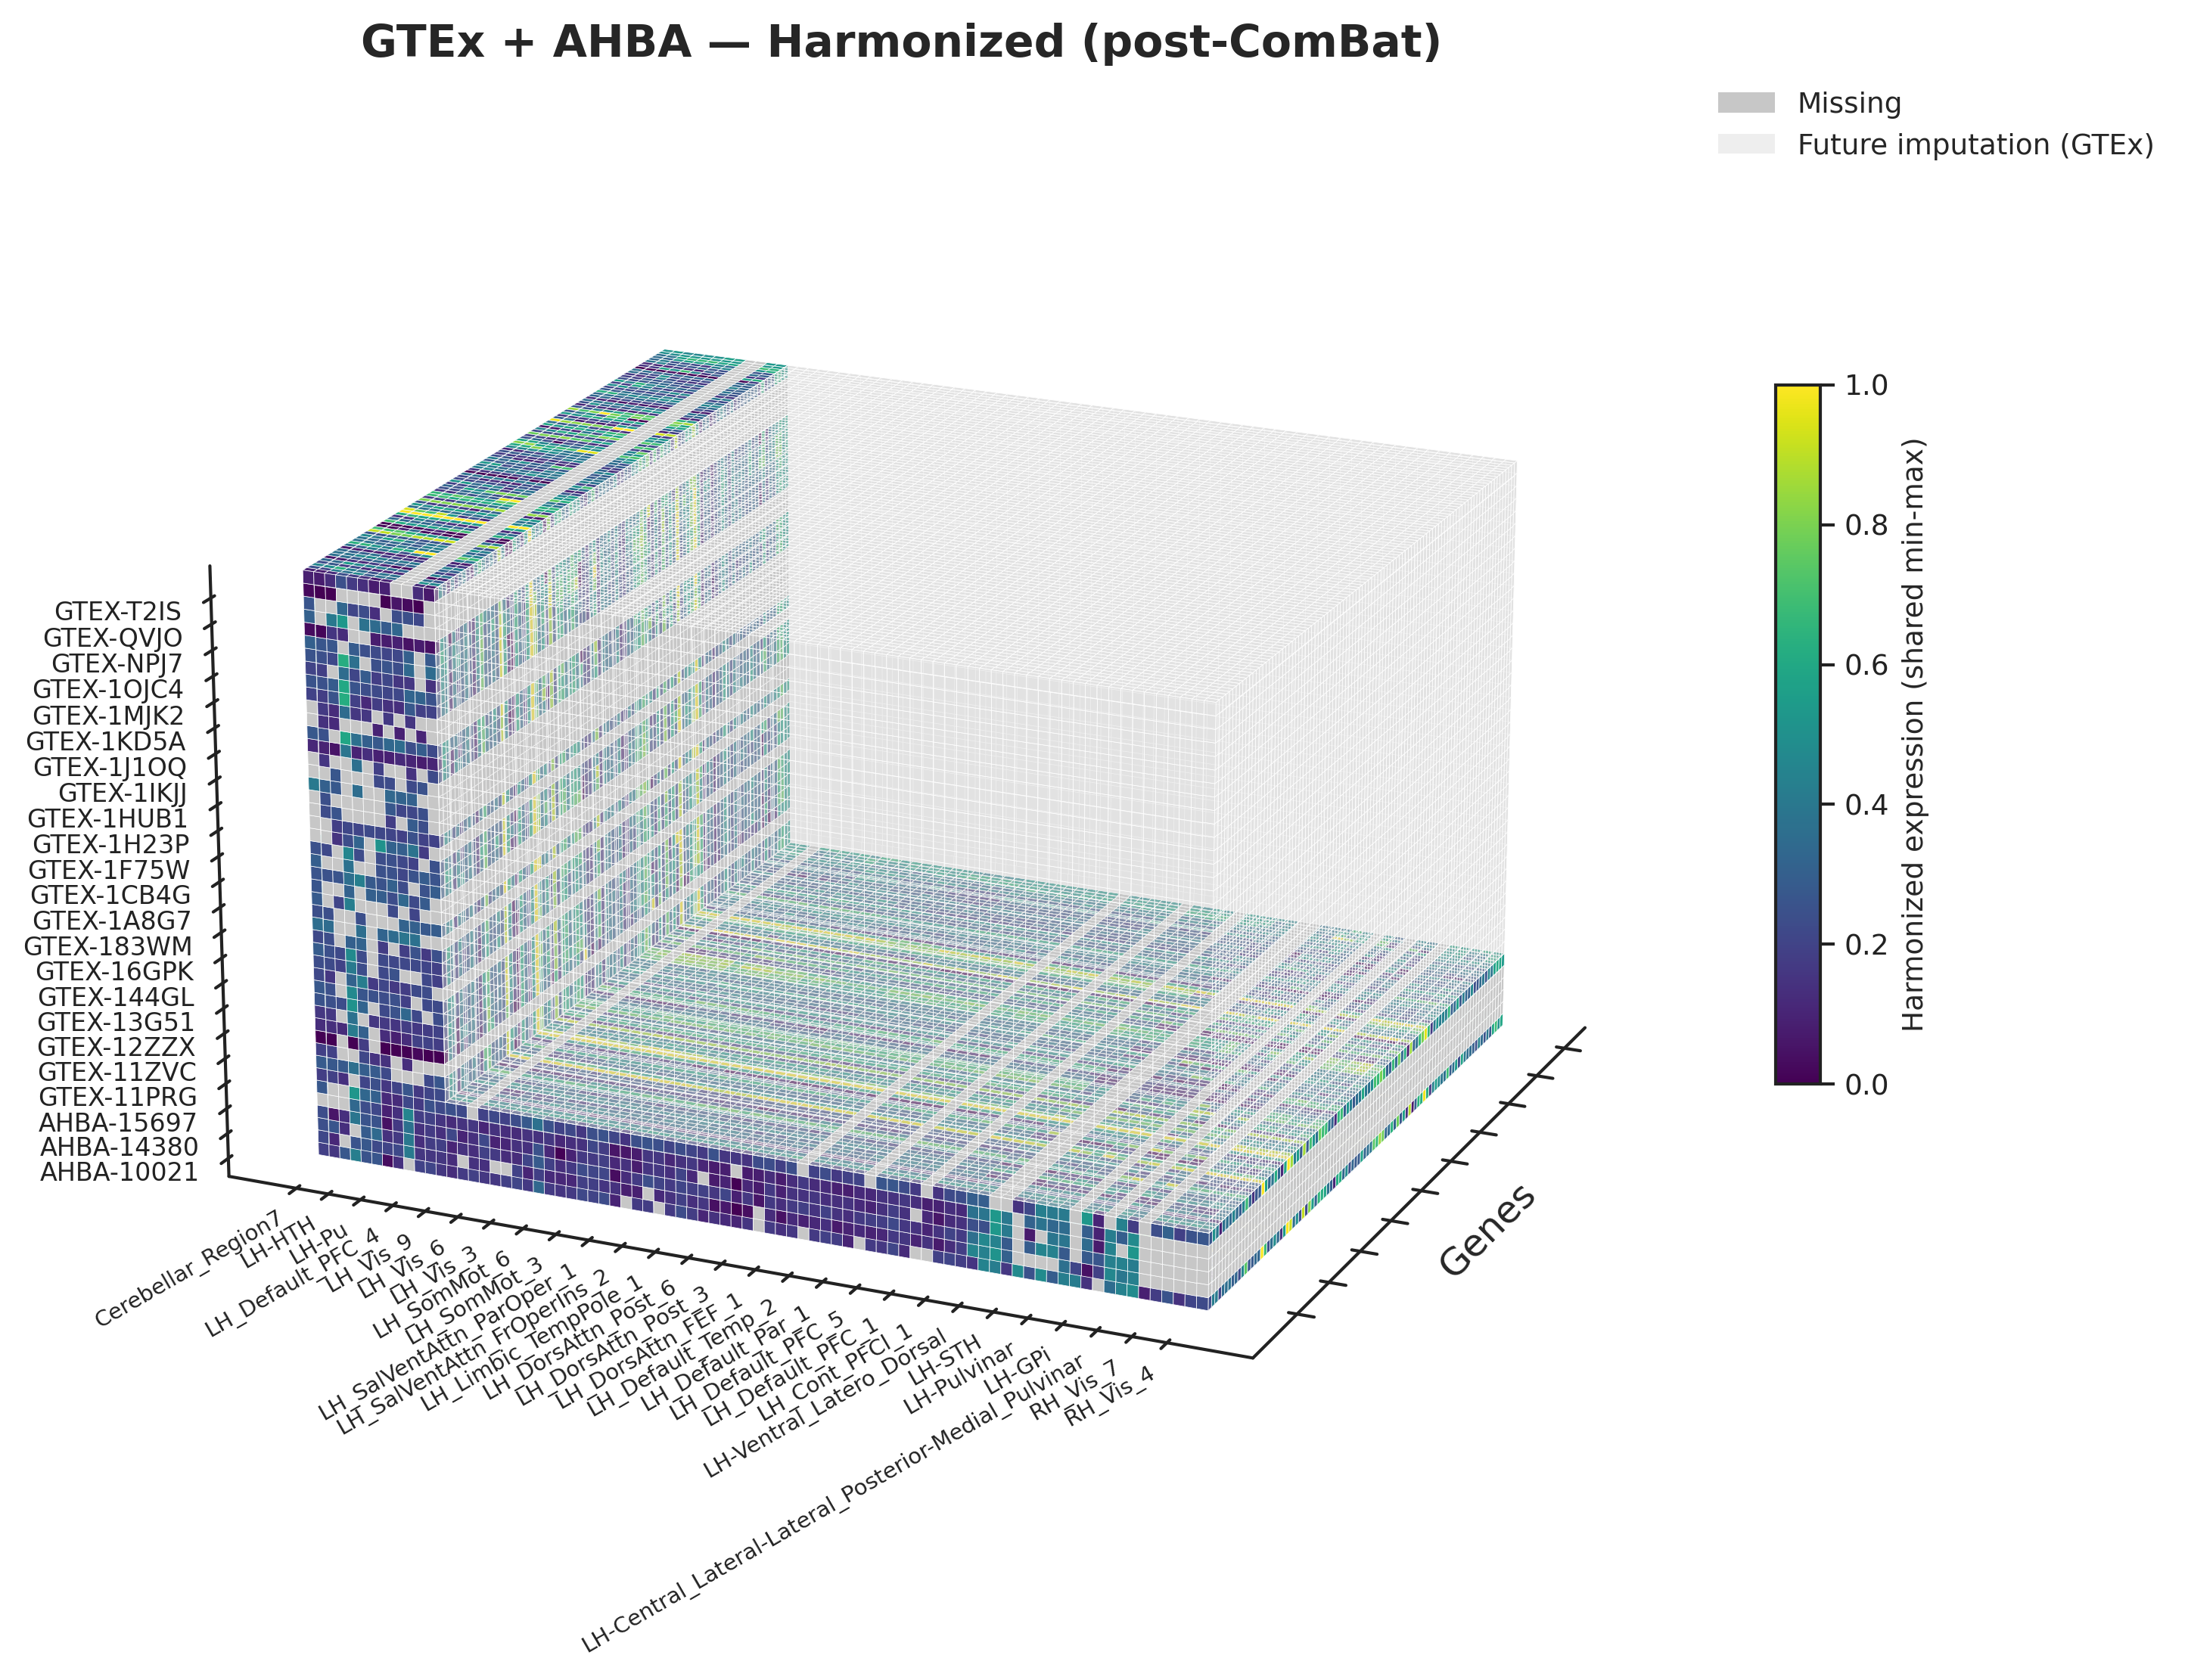

{'AHBA': (0.669781893491745, 8.661295413970947),
 'GTEx': (0.669781893491745, 8.661295413970947)}

In [9]:
fig_h, ax_h = plot_joint_tensor_voxels(
    harmonized_joint,
    missing_rgba=(0.78, 0.78, 0.78, MISSING_ALPHA),
    future_imputation_rgba=(0.78, 0.78, 0.78, FUTURE_IMPUTATION_ALPHA),
    figsize=FIGSIZE, dpi=DPI, axes_bbox=AXES_BBOX, colorbar_bbox=COLORBAR_BBOX,
    box_aspect=BOX_ASPECT, box_zoom=BOX_ZOOM, title_pad=TITLE_PAD,
    axis_assignment=AXIS_ASSIGNMENT, elev=ELEV, azim=AZIM,
    subject_tick_step=SUBJECT_TICK_STEP, gene_tick_step=GENE_TICK_STEP, region_tick_step=REGION_TICK_STEP,
    tick_label_pad=TICK_LABEL_PAD,
    subject_label_mode=SUBJECT_LABEL_MODE, gene_label_mode=GENE_LABEL_MODE,
    show_x_axis_label=SHOW_X_AXIS_LABEL, show_y_axis_label=SHOW_Y_AXIS_LABEL,
    show_z_axis_label=SHOW_Z_AXIS_LABEL, show_axis_labels=SHOW_AXIS_LABELS,
    show_subject_ticklabels=SHOW_SUBJECT_TICKLABELS, show_region_ticklabels=SHOW_REGION_TICKLABELS,
    show_region_label_colors=SHOW_REGION_LABEL_COLORS, show_gene_ticklabels=SHOW_GENE_TICKLABELS,
    show_axis_lines=SHOW_AXIS_LINES, show_tick_lines=SHOW_TICK_LINES,
    show_grid=SHOW_GRID, show_legend=SHOW_LEGEND,
    dataset_gap=DATASET_GAP, mask_render_mode=MASK_RENDER_MODE,
    normalization='shared',
)
ax_h.set_title('GTEx + AHBA — Harmonized (post-ComBat)', pad=float(TITLE_PAD))
plt.show()
ax_h._joint_dataset_ranges

## Next: Phase 5 — Predictions

`build_prediction_tensor_view(cache_root, model_name, dataset, stage, cfg, matching_context=ctx, ...)` reuses the same adapter chokepoint. Stages: `'loro_truth'`, `'loro_recon'`, `'loro_fused'`, `'fullfit'`. The `stack_subject_cubes(...)` npz reader is currently a stub — that's the one piece of new code Phase 5 needs.